# Resistor Value Detection — Quickstart

End-to-end pipeline: **Image → YOLO Detection → Segmentation → Band Extraction → Resistance Value**

# 1. Set up

In [1]:
%pip install ultralytics segmentation-models-pytorch albumentations pillow matplotlib scikit-learn opencv-python


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# 2. Load weights

In [3]:
import os, sys, tempfile
import numpy as np
from PIL import Image
import torch
import matplotlib.pyplot as plt
import cv2

REPO_ROOT = os.path.abspath("..")
DETECTION_WEIGHTS = os.path.join(REPO_ROOT, "weights", "detection", "best.pt")
SEG_CHECKPOINT = os.path.join(REPO_ROOT, "weights", "segmentation", "efficientnet-b2_best.pt")

sys.path.insert(0, os.path.join(REPO_ROOT, "segmentation"))
sys.path.insert(0, os.path.join(REPO_ROOT, "band_extraction"))

from ultralytics import YOLO
from infer import load_model, run_inference
from dataset import get_val_transform, IMG_SIZE
from resistance_calculator import calculate_resistance, calculate_resistance_with_axis_info
from color_code_tables import format_resistance, ResistanceResult

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
yolo      = YOLO(DETECTION_WEIGHTS)
seg_model = load_model(SEG_CHECKPOINT, device)
transform = get_val_transform()

print(f"Ready  |  device={device}  |  detection={os.path.exists(DETECTION_WEIGHTS)}  |  seg={os.path.exists(SEG_CHECKPOINT)}")

Loaded checkpoint: /Users/ramaalhamidi/resistor-value-detection/weights/segmentation/efficientnet-b2_best.pt
Ready  |  device=cpu  |  detection=True  |  seg=True


# 3. Pipeline Function

In [4]:
def _nms_boxes(boxes_xyxy, confs, iou_thresh=0.5):
    if len(boxes_xyxy) == 0:
        return []
    order = sorted(range(len(confs)), key=lambda i: confs[i], reverse=True)
    kept, suppressed = [], set()
    for i in order:
        if i in suppressed:
            continue
        kept.append(i)
        x1i, y1i, x2i, y2i = boxes_xyxy[i]
        ai = max(0, x2i-x1i) * max(0, y2i-y1i)
        for j in order:
            if j in suppressed or j == i:
                continue
            x1j, y1j, x2j, y2j = boxes_xyxy[j]
            inter = max(0, min(x2i,x2j)-max(x1i,x1j)) * max(0, min(y2i,y2j)-max(y1i,y1j))
            if inter == 0:
                continue
            aj = max(0, x2j-x1j) * max(0, y2j-y1j)
            if inter / (ai + aj - inter + 1e-6) > iou_thresh:
                suppressed.add(j)
    return kept

def run_pipeline(image_path: str):
    img_bgr = cv2.imread(image_path)
    img_np  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    results = yolo(image_path, verbose=False, conf=0.01)  # was 0.1
    if not results or len(results[0].boxes) == 0:
        print("No resistors detected.")
        return [], results

    raw_boxes = [box.xyxy[0].tolist() for box in results[0].boxes]
    raw_confs = [float(box.conf[0])   for box in results[0].boxes]
    keep_idx  = _nms_boxes(raw_boxes, raw_confs)
    kept_boxes = [results[0].boxes[i] for i in keep_idx]

    outputs = []
    for box in kept_boxes:          # was: for box in results[0].boxes
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        h, w = img_np.shape[:2]
        bw, bh = x2-x1, y2-y1
        x1 = max(0, x1 - int(bw*.1));  y1 = max(0, y1 - int(bh*.1))
        x2 = min(w, x2 + int(bw*.1));  y2 = min(h, y2 + int(bh*.1))
        crop_np = img_np[y1:y2, x1:x2]
        if min(crop_np.shape[:2]) < 50:
            continue
        with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as tmp:
            tmp_path = tmp.name
        cv2.imwrite(tmp_path, cv2.cvtColor(crop_np, cv2.COLOR_RGB2BGR))
        mask, vis, seg_conf = run_inference(seg_model, tmp_path, transform, device, IMG_SIZE)
        os.unlink(tmp_path)
        result = calculate_resistance(mask)
        if not isinstance(result, ResistanceResult):
            continue
        outputs.append({
            "crop": Image.fromarray(crop_np), "mask": mask,
            "vis": vis, "seg_conf": seg_conf,
            "result": result, "box": box,
        })
    return outputs, results


# Helper Functions

In [5]:
_COLOR_HEX = {
    'black':'#1a1a1a','blue':'#004aad','brown':'#5e3831','gold':'#ebbf7c',
    'green':'#00bf63','grey':'#585a59','orange':'#ff914d','violet':'#9417eb',
    'red':'#e43232','silver':'#c0c0c0','white':'#f5f5f5','yellow':'#f4cb24',
}
_CIRCLED = '①②③④⑤⑥'
PANEL_H  = 300
GAP_PX   = 10

def _rh(arr, h):
    im = Image.fromarray(arr.astype(np.uint8))
    s  = h / im.height
    nw = max(1, int(im.width * s))
    return np.array(im.resize((nw, h), Image.LANCZOS)), s

def get_band_category(idx, total):
    cats = (['D1','D2','×','±'] if total == 4
            else ['D1','D2','D3','×','±'] if total == 5
            else [f'B{k+1}' for k in range(total)])
    return cats[idx] if idx < len(cats) else f'B{idx+1}'

def _seg_overlay(crop_arr, vis_arr, alpha=0.55):
    nonzero = vis_arr.sum(axis=2) > 0
    out = crop_arr.copy()
    out[nonzero] = (alpha * vis_arr[nonzero] + (1-alpha) * crop_arr[nonzero]).astype(np.uint8)
    return out

def combined_confidence(det_conf, seg_conf, axis_conf, area_conf):
    pca_conf = (axis_conf + area_conf) / 2
    return (det_conf * seg_conf * pca_conf) ** (1/3)

def _draw_p3(arr, bands, axis_info, s3, crop_arr):
    out = arr.copy()
    if not (axis_info and bands):
        return out
    h_c, w_c = crop_arr.shape[:2]
    av   = np.array(axis_info['axis_vector'])
    ao   = np.array(axis_info['axis_origin']) * s3
    perp = np.array([-av[1], av[0]])
    tick = int(max(14, int(min(h_c, w_c) * 0.20) * s3))
    H, W = out.shape[:2]
    t    = max(W, H)
    cv2.line(out,
             (int(ao[0]-t*av[0]), int(ao[1]-t*av[1])),
             (int(ao[0]+t*av[0]), int(ao[1]+t*av[1])),
             (180, 180, 180), 1, cv2.LINE_AA)
    for j, band in enumerate(bands):
        cx, cy = int(band.centroid[0] * s3), int(band.centroid[1] * s3)
        hx  = _COLOR_HEX.get(band.color_name.lower(), '#ffffff')
        col = (int(hx[1:3],16), int(hx[3:5],16), int(hx[5:7],16))
        cv2.line(out,
                 (int(cx-perp[0]*tick), int(cy-perp[1]*tick)),
                 (int(cx+perp[0]*tick), int(cy+perp[1]*tick)),
                 (255,255,255), 2, cv2.LINE_AA)
        cv2.circle(out, (cx, cy), 9, col,          -1, cv2.LINE_AA)
        cv2.circle(out, (cx, cy), 9, (255,255,255),  1, cv2.LINE_AA)
        tc = (20,20,20) if band.color_name in ('white','gold','yellow','silver') else (255,255,255)
        cv2.putText(out, str(j+1), (cx-4, cy+4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.3, tc, 1, cv2.LINE_AA)
    return out

def display_results(detections, raw_results):
    if not detections:
        print("Nothing to display.")
        return

    orig = np.array(Image.open(IMAGE_PATH).convert("RGB"))
    n    = len(detections)

    results_summary = []

    fig, axes = plt.subplots(n, 1,
                             figsize=(14, (PANEL_H/100 + 0.6) * n),
                             gridspec_kw={'hspace': 0.3},
                             facecolor='white')
    if n == 1:
        axes = [axes]

    for i, det in enumerate(detections):
        box      = det["box"]
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        det_conf = float(box.conf[0])
        seg_conf = det["seg_conf"]
        result   = det["result"]
        conf     = combined_confidence(det_conf, seg_conf,
                                       result.axis_confidence, result.area_confidence)
        results_summary.append((i + 1, result, conf, box))

        crop_arr = np.array(det["crop"])
        vis_arr  = det["vis"]

        result2, axis_info = calculate_resistance_with_axis_info(det["mask"])
        bands = (result2.bands if isinstance(result2, ResistanceResult)
                 else getattr(result2, 'detected_bands', []))

        # All panels exactly PANEL_H px tall — equal by construction
        det_img = orig.copy()
        cv2.rectangle(det_img, (x1, y1), (x2, y2), (0, 210, 0), 2)
        p1, s1   = _rh(det_img, PANEL_H)
        p2, _    = _rh(_seg_overlay(crop_arr, vis_arr, 0.6),  PANEL_H)
        p3b, s3  = _rh(_seg_overlay(crop_arr, vis_arr, 0.30), PANEL_H)
        p3       = _draw_p3(p3b, bands, axis_info, s3, crop_arr)

        gap    = np.full((PANEL_H, GAP_PX, 3), 245, dtype=np.uint8)
        row    = np.concatenate([p1, gap, p2, gap, p3], axis=1)
        p1_w   = p1.shape[1]
        p3_off = p1_w + GAP_PX + p2.shape[1] + GAP_PX

        ax = axes[i]
        ax.imshow(row)
        ax.axis('off')

        # Panel 1 badge
        ax.text((x1+4)*s1, (y1-4)*s1, f"resistor  {det_conf:.2f}",
        fontsize=8, color='white', fontweight='bold', va='bottom',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#00b300',
                  edgecolor='none', alpha=0.88))


        # Titles above first row only
        if i == 0:
            for txt, xc in [('(a) Detection',     p1_w / 2),
                             ('(b) Segmentation',  p1_w + GAP_PX + p2.shape[1] / 2),
                             ('(c) Band Extraction', p3_off + p3.shape[1] / 2)]:
                ax.text(xc, -8, txt, fontsize=11, fontweight='bold',
                        color='#1a1a1a', ha='center', va='bottom', clip_on=False)

        if bands:
            cats   = [get_band_category(j, len(bands)) for j in range(len(bands))]
            legend = '   '.join(
                f"{_CIRCLED[j]} {b.color_name.capitalize()} ({cats[j]})"
                for j, b in enumerate(bands) if j < 6
            )
            ax.set_xlabel(legend, fontsize=7.5, color='#333333', labelpad=6)

    plt.show()

    # ── Final output ──────────────────────────────────────────────────────
    fig_out, ax_out = plt.subplots(figsize=(10, 6), facecolor='white')
    ax_out.imshow(orig)
    ax_out.axis('off')

    for idx, result, conf, box in results_summary:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        ax_out.add_patch(plt.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            lw=2, edgecolor='#2ecc71', facecolor='#2ecc7115', zorder=2
        ))
        label = f"{format_resistance(result.value)}  ±{result.tolerance}%   conf {conf:.2f}"
        ax_out.text(x1+4, y1-4, label,
            fontsize=9, color='white', fontweight='bold', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#00b300',
                      edgecolor='none', alpha=0.88))


    plt.tight_layout(pad=0.5)
    plt.show()

    print("─" * 55)
    for idx, result, conf, _ in results_summary:
        print(f"  Resistor {idx}: {format_resistance(result.value)}"
              f"  ±{result.tolerance}%   conf={conf:.2f}")
    print("─" * 55)


# 4. Run on an image

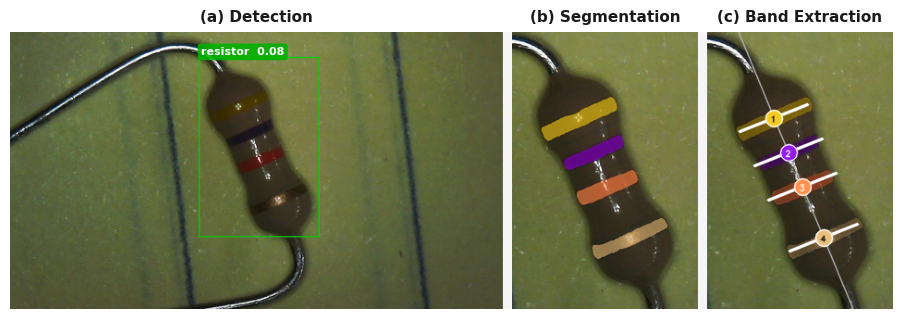

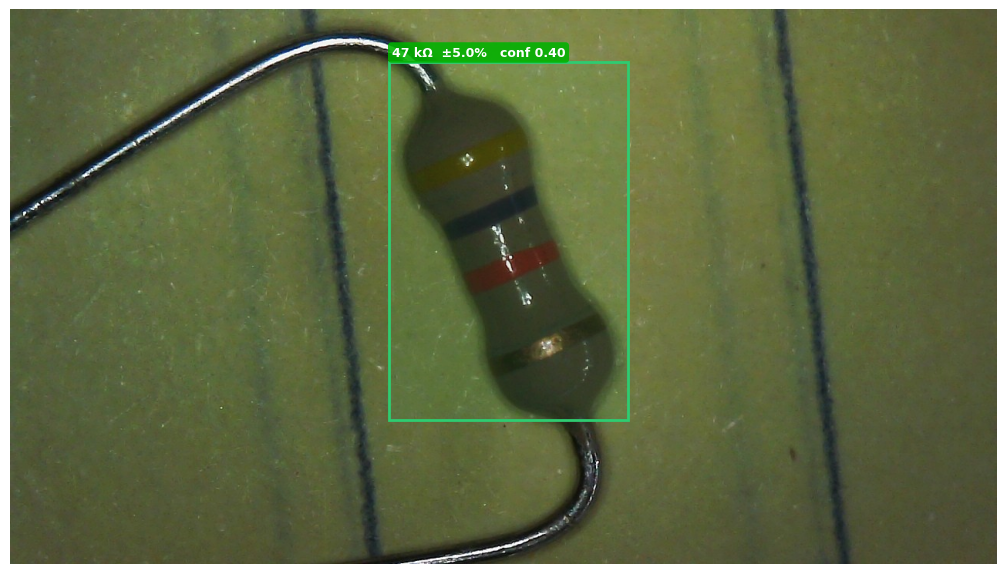

───────────────────────────────────────────────────────
  Resistor 1: 47 kΩ  ±5.0%   conf=0.40
───────────────────────────────────────────────────────


In [8]:
IMAGE_PATH = os.path.join(REPO_ROOT, "datasets/test/4B-47K-T5-8_jpg.rf.SC8kwjuGYkiuOuTwqnei.jpg")

# Run
detections, raw = run_pipeline(IMAGE_PATH)
display_results(detections, raw)

# 5. Run on a whole folder

In [7]:
FOLDER = os.path.join(REPO_ROOT, "datasets/test")
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

images = sorted(
    os.path.join(FOLDER, f) for f in os.listdir(FOLDER)
    if os.path.splitext(f)[1].lower() in IMG_EXTS
)
print(f"Running on {len(images)} images...\n")

correct = total = 0
for path in images:
    dets, _ = run_pipeline(path)
    fname = os.path.basename(path)
    if not dets:
        print(f"  {fname}: no detection")
        continue
    for det in dets:
        r = det["result"]
        total += 1
        if isinstance(r, ResistanceResult):
            correct += 1
            print(f"  {fname}: {format_resistance(r.value)}  +/-{r.tolerance}%")
        else:
            print(f"  {fname}: ERROR — {r.error_type}")

print(f"\nSummary: {correct}/{total} successfully read  ({100*correct/total:.1f}%)" if total else "\nNo resistors found.")

Running on 106 images...

  4B-100R-T5-8_jpg.rf.rR0rwKcCmVPXlXFM1JNQ.jpg: 100 Ω  +/-5.0%
  4B-10R-T5-2_jpg.rf.QD52rc1rhxiRwdBkYq68.jpg: 10 Ω  +/-5.0%
  4B-120K-T5-4_jpg.rf.5vxqDZGVOKdKzmvNKiFi.jpg: 120 kΩ  +/-5.0%
  4B-12K-T5-5_jpg.rf.jCde1ZqMftnCVaNZ2kAc.jpg: 12 kΩ  +/-5.0%
  4B-12R-T5-5_jpg.rf.gcDxD9ZQIdPo8MczHLRl.jpg: 12 Ω  +/-5.0%
  4B-150R-T5-4_jpg.rf.bNF6zAurQAlluicNNZbX.jpg: 15.1 Ω  +/-20.0%
  4B-150R-T5-5_jpg.rf.sgYFbOkCCrew4fRMUmjR.jpg: 150 Ω  +/-5.0%
  4B-180K-T5-3_jpg.rf.A7RauX8aTjWlMA9PN46z.jpg: 180 kΩ  +/-5.0%
  4B-18R-T5-10_jpg.rf.EriAV0mFQj0F3DyFF7aq.jpg: 18 Ω  +/-5.0%
  4B-18R-T5-3_jpg.rf.IlHxB995HxfZIKbI5Qda.jpg: 18 Ω  +/-5.0%
  4B-1K-T5-3_jpg.rf.zSU2sFyK1rNB44QjVfXF.jpg: 1 kΩ  +/-5.0%
  4B-1K8-T5-10_jpg.rf.VPfQflBhahjqlvcfpMBo.jpg: 1.8 kΩ  +/-5.0%
  4B-1M-T5-10_jpg.rf.jNsh6zPt7K745RdrphQa.jpg: 1 MΩ  +/-5.0%
  4B-1M-T5-2_jpg.rf.MOJIZN9fGMrN7dtc8ek8.jpg: 1 MΩ  +/-5.0%
  4B-1M-T5-4_jpg.rf.jfukgzKd9p2fOFHGm3Ej.jpg: 1 MΩ  +/-5.0%
  4B-1M-T5-5_jpg.rf.FJB7AO21vxMq9nRevw1o.jp